<a href="https://colab.research.google.com/github/mlnjsh/Introduction-to-Deep-Learning/blob/main/notebooks_DeepLearning/10_lr_schedules_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 10. Learning-Rate Schedules — PyTorch

PyTorch schedules live in `torch.optim.lr_scheduler` and are stepped **once per epoch** inside your loop. We compare **Constant, StepLR, ExponentialLR, CosineAnnealingLR, and ReduceLROnPlateau**.

**Dataset:** `loan_prediction_data.csv` — 614 loan applications, 11 pre-normalised features, binary target `Loan_Status` (1 = approved).

> This is the PyTorch twin of `10_..._keras.ipynb`. Where Keras hides the training loop inside `model.fit`, here we **write the loop explicitly** — that is the main thing to compare.

---

## 1. Setup & imports

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch", torch.__version__, "| device:", device)

PyTorch 2.11.0+cpu | device: cpu


## 2. Load the data

In [2]:
import os, numpy as np, pandas as pd
from sklearn.model_selection import train_test_split

# Robust load: works whether the notebook runs from its own folder or the parent
CSV = "loan_prediction_data.csv"
if not os.path.exists(CSV):
    CSV = os.path.join("..", "loan_prediction_data.csv")

df = pd.read_csv(CSV)
print("Shape:", df.shape)
df.head()

Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,0.0,0.0,0.000000,1.0,0.0,0.070489,0.000000,0.198860,0.74359,1.0,1.0,1.0
1,LP001003,0.0,1.0,0.333333,1.0,0.0,0.054830,0.036192,0.172214,0.74359,1.0,0.0,0.0
2,LP001005,0.0,1.0,0.000000,1.0,1.0,0.035250,0.000000,0.082489,0.74359,1.0,1.0,1.0
3,LP001006,0.0,1.0,0.000000,0.0,0.0,0.030093,0.056592,0.160637,0.74359,1.0,1.0,1.0
4,LP001008,0.0,0.0,0.000000,1.0,0.0,0.072356,0.000000,0.191027,0.74359,1.0,1.0,1.0


## 3. Prepare features & train/test split

Features are already scaled to `[0,1]`; we drop the ID and do a **stratified** split.

In [3]:
# Features are ALREADY normalised to [0,1] in this dataset, so no scaling needed.
# Drop the ID column and separate the target.
X = df.drop(columns=["Loan_ID", "Loan_Status"]).values.astype("float32")
y = df["Loan_Status"].values.astype("float32")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
N_FEATURES = X_train.shape[1]
print("Train:", X_train.shape, " Test:", X_test.shape, " Features:", N_FEATURES)
print("Train positive rate: %.3f  Test positive rate: %.3f" % (y_train.mean(), y_test.mean()))

Train: (491, 11)  Test: (123, 11)  Features: 11
Train positive rate: 0.686  Test positive rate: 0.691


In [4]:
# Wrap the numpy arrays as float tensors. Target is shaped (N,1) to match the
# sigmoid output and BCELoss.
Xtr = torch.tensor(X_train)
ytr = torch.tensor(y_train).view(-1, 1)
Xte = torch.tensor(X_test)
yte = torch.tensor(y_test).view(-1, 1)
print("Xtr", tuple(Xtr.shape), "| ytr", tuple(ytr.shape))

Xtr (491, 11) | ytr (491, 1)


In [5]:
def plot_history(hist, title=""):
    """Plot train (solid) vs test (dashed) loss and accuracy over epochs."""
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(hist["loss"], label="train")
    ax[0].plot(hist["val_loss"], "--", label="test")
    ax[0].set_title(title + " — Loss"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss")
    ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(hist["accuracy"], label="train")
    ax[1].plot(hist["val_accuracy"], "--", label="test")
    ax[1].set_title(title + " — Accuracy"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy")
    ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

## 4. A loop that steps a scheduler each epoch

The key detail: record the LR **used during** the epoch (before `scheduler.step()`), and note that `ReduceLROnPlateau.step()` takes the validation loss as an argument while the others take none.

In [6]:
import torch.optim.lr_scheduler as sched_mod

EPOCHS = 120
BASE_LR = 0.1

def make_model():
    torch.manual_seed(42)
    return nn.Sequential(
        nn.Linear(N_FEATURES, 32), nn.ReLU(),
        nn.Linear(32, 1), nn.Sigmoid(),
    )

def make_scheduler(name, opt):
    if name == "StepLR":            return sched_mod.StepLR(opt, step_size=30, gamma=0.5)
    if name == "ExponentialLR":     return sched_mod.ExponentialLR(opt, gamma=0.97)
    if name == "CosineAnnealing":   return sched_mod.CosineAnnealingLR(opt, T_max=EPOCHS)
    if name == "ReduceLROnPlateau": return sched_mod.ReduceLROnPlateau(opt, factor=0.5,
                                                                       patience=10, min_lr=1e-4)
    return None   # "Constant"

def train_with_sched(name, epochs=EPOCHS):
    model = make_model()
    opt = torch.optim.SGD(model.parameters(), lr=BASE_LR)
    sched = make_scheduler(name, opt)
    loss_fn = nn.BCELoss()
    loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=32, shuffle=True)
    hist = {"val_loss": [], "val_accuracy": []}
    lrs = []
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            opt.zero_grad(); loss_fn(model(xb), yb).backward(); opt.step()
        lrs.append(opt.param_groups[0]["lr"])          # LR used this epoch
        model.eval()
        with torch.no_grad():
            te = model(Xte); vl = loss_fn(te, yte).item()
            hist["val_loss"].append(vl)
            hist["val_accuracy"].append((((te > 0.5) == (yte > 0.5)).float().mean()).item())
        if name == "ReduceLROnPlateau":
            sched.step(vl)                              # adaptive: needs the metric
        elif sched is not None:
            sched.step()                                # deterministic: no argument
    return hist, lrs

## 5. Train with each schedule

In [7]:
names = ["Constant", "StepLR", "ExponentialLR", "CosineAnnealing", "ReduceLROnPlateau"]
histories, lr_curves = {}, {}
for name in names:
    histories[name], lr_curves[name] = train_with_sched(name)
    print("%-18s best test acc = %.3f | final test loss = %.3f" %
          (name, max(histories[name]["val_accuracy"]), histories[name]["val_loss"][-1]))

Constant           best test acc = 0.862 | final test loss = 0.397


StepLR             best test acc = 0.854 | final test loss = 0.403


ExponentialLR      best test acc = 0.854 | final test loss = 0.415


CosineAnnealing    best test acc = 0.854 | final test loss = 0.403


ReduceLROnPlateau  best test acc = 0.862 | final test loss = 0.398


## 6. The schedules and their effect

Left: how each learning rate evolves (log scale). Right: the resulting test loss.

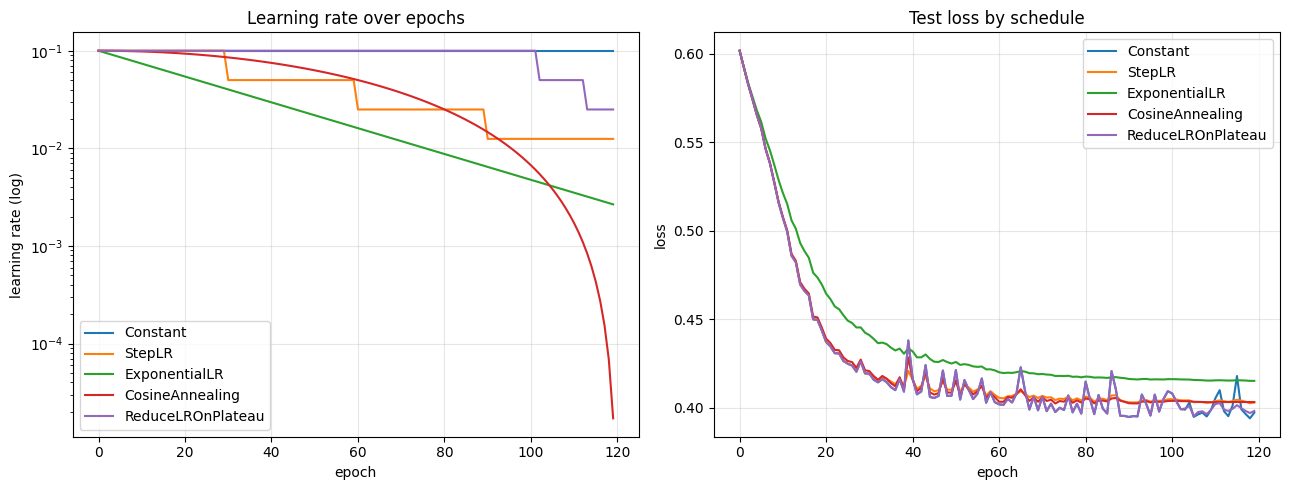

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for name in names:
    ax[0].plot(lr_curves[name], label=name)
    ax[1].plot(histories[name]["val_loss"], label=name)
ax[0].set_title("Learning rate over epochs"); ax[0].set_yscale("log")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("learning rate (log)")
ax[1].set_title("Test loss by schedule"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("loss")
for a in ax: a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 7. Summary table

In [9]:
summary = pd.DataFrame({
    name: {
        "best_test_acc":   max(histories[name]["val_accuracy"]),
        "final_test_loss": histories[name]["val_loss"][-1],
        "final_lr":        lr_curves[name][-1],
    } for name in names
}).T.sort_values("best_test_acc", ascending=False)
summary.round(4)

,best_test_acc,final_test_loss,final_lr
Constant,0.8618,0.3973,0.1000
ReduceLROnPlateau,0.8618,0.3983,0.0250
StepLR,0.8537,0.4031,0.0125
ExponentialLR,0.8537,0.4153,0.0027
CosineAnnealing,0.8537,0.4034,0.0000


## Takeaways
- Schedulers are stepped **inside your loop**, once per epoch — `ReduceLROnPlateau.step(val_loss)` takes the metric; all others take no argument. Mixing these up is a common bug.
- **StepLR / ExponentialLR / CosineAnnealing** are deterministic decays; **CosineAnnealing** smoothly anneals to ~0 and is popular in modern training.
- **ReduceLROnPlateau** is adaptive — it reacts to the loss curve, so you don't hand-design the decay.
- Read the LR from `optimizer.param_groups[0]["lr"]` — the single source of truth for the current rate.
- This is the PyTorch twin of `10_lr_schedules_keras`; the Keras callback API hides the per-epoch stepping that you write explicitly here.